In [10]:
from ultralytics import YOLO
MODEL_PATH = 'yolo11m-pose.pt'
IMAGE_PATH = '/media/amrit/sda2/pedal_ball_analysis/input/image.png'

In [12]:
model = YOLO(MODEL_PATH)
results = model(IMAGE_PATH)

results


image 1/1 /media/amrit/sda2/pedal_ball_analysis/input/image.png: 352x640 1 person, 339.5ms
Speed: 1.6ms preprocess, 339.5ms inference, 0.8ms postprocess per image at shape (1, 3, 352, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: ultralytics.engine.results.Keypoints object
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [ 87, 119, 118],
         [ 92, 124, 123],
         [ 92, 124, 123]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [ 88, 120, 119],
         [ 90, 122, 122],
         [ 92, 124, 123]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [ 88, 120, 121],
         [ 88, 120, 121],
         [ 87, 118, 120]],
 
        ...,
 
        [[  0,   3,   2],
         [  0,   3,   2],
         [  0,   3,   2],
         ...,
         [ 36,  72,  80],
         [ 65, 102, 110],
         [ 73, 110, 118]],
 
        [[  0,   3,   2],
         [  0,   3,   2],
         [  0,   3,

Keypoints tensor shape (xy): torch.Size([1, 17, 2])
Keypoints (xy):
 tensor([[[1373.1562,  437.0278],
         [1378.0920,  433.9404],
         [1375.2867,  432.1333],
         [1394.1384,  435.0049],
         [1380.8015,  430.8648],
         [1412.1354,  457.6195],
         [1373.5977,  447.2666],
         [1424.7850,  490.8085],
         [1355.9117,  467.0725],
         [1404.6006,  521.9230],
         [1344.5927,  495.0312],
         [1390.3481,  513.6789],
         [1366.9468,  506.9648],
         [1377.6458,  541.5089],
         [1357.6677,  535.1899],
         [1367.3068,  570.9576],
         [1354.5060,  562.8773]]])
Keypoint confidence shape: torch.Size([1, 17])
Keypoint confidence:
 tensor([[0.7189, 0.7861, 0.3033, 0.8114, 0.0518, 0.9889, 0.9704, 0.9807, 0.8802, 0.9635, 0.8639, 0.9947, 0.9915, 0.9854, 0.9735, 0.9580, 0.9353]])


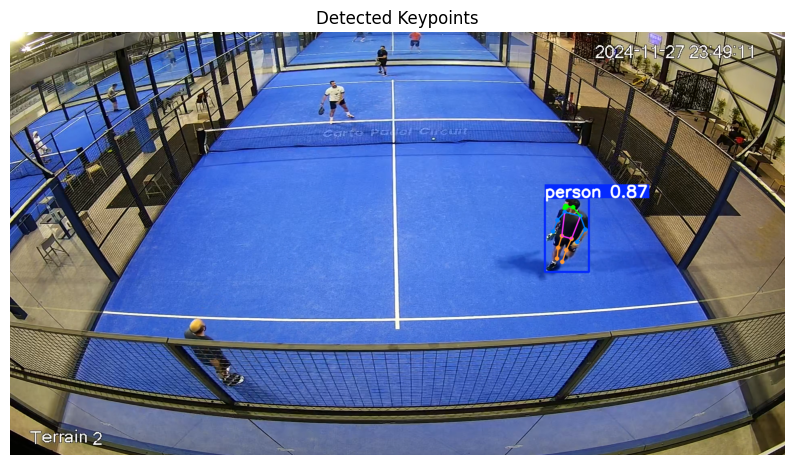

In [15]:
import matplotlib.pyplot as plt

# First image result (you already ran inference in previous cell)
res = results[0]
kpts = res.keypoints

# Raw keypoint outputs
if kpts is None:
    print("No keypoints detected.")
else:
    print("Keypoints tensor shape (xy):", kpts.xy.shape)  # (num_people, num_keypoints, 2)
    print("Keypoints (xy):\n", kpts.xy)

    if kpts.conf is not None:
        print("Keypoint confidence shape:", kpts.conf.shape)  # (num_people, num_keypoints)
        print("Keypoint confidence:\n", kpts.conf)

    # Visualize keypoints on image
    annotated = res.plot(kpt_radius=5, kpt_line=True)  # BGR image
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated[:, :, ::-1])  # BGR -> RGB
    plt.axis("off")
    plt.title("Detected Keypoints")
    plt.show()